# SNN Simulation from Scratch

Spiking Neural Network implementation using discrete-time LIF neurons.

In [142]:
import json
import math
import pandas as pd
import matplotlib.pyplot as plt
import pprint

network_path = 'results/best.json'

with open(network_path, 'r') as f:
    network_config = json.load(f)

print(f'Network loaded from: {network_path}')
print(f'Network config:')
pprint.pprint(network_config)

Network loaded from: results/best.json
Network config:
{'Associated_Data': {'application': {'encoder_ticks': 1},
                     'processor': {'Leak_Enable': True,
                                   'Max_Axon_Delay': 0,
                                   'Max_Leak': 4,
                                   'Max_Synapse_Delay': 255,
                                   'Max_Threshold': 127,
                                   'Max_Weight': 127,
                                   'Min_Axon_Delay': 0,
                                   'Min_Leak': -1,
                                   'Min_Synapse_Delay': 0,
                                   'Min_Threshold': 0,
                                   'Min_Weight': -127}},
 'Edges': [{'from': 2, 'to': 1, 'values': [28.0, 224.0]},
           {'from': 0, 'to': 2, 'values': [85.0, 158.0]},
           {'from': 2, 'to': 4, 'values': [-41.0, 75.0]},
           {'from': 2, 'to': 2, 'values': [-112.0, 130.0]},
           {'from': 1, 'to': 4, 'values':

In [139]:
num_neurons = len(network_config.get('Nodes', []))
num_synapses = len(network_config.get('Edges', []))

print(f'Network: {num_neurons} neurons, {num_synapses} synapses')

Network: 6 neurons, 13 synapses


### LIF Neuron Model from scratch

In [ ]:
# Found from Caspian
MAX_CHARGE = 32767   # 16-bit signed integer range
MIN_CHARGE = -32768
MAX_LEAK = 4
COMP_BITS = 10
LEAK_COMP = (  # these are leak multipliers. need to divide by 2^10 = 1024 to get actual leak factors. i.e. 512/1024 = 0.5 (high leak), 981/1024 = 0.981 (low leak)
    512, 535, 558, 583, 609, 636, 664, 693, 724, 756, 790, 825, 861, 899, 939, 981)

MAX_DEVICE_INPUT = 255  # caspian::constants::MAX_DEVICE_INPUT. So inputs are 8 bits (but in my case input is binary)
MAX_TIME = (1 << 63) - 1 # 64-bit integer. Basically infinity for our purposes


def clamp(value, min_value, max_value):
    return max_value if value > max_value else (min_value if value < min_value else value)


def next_pow_of_2(v): # finds the next power of 2 that is greater than or equal to v, i.e. next_pow_of_2(7) = 8
    v -= 1
    v |= v >> 1
    v |= v >> 2
    v |= v >> 4
    v |= v >> 8
    v |= v >> 16
    v += 1
    return v


class LIFNeuron:
    def __init__(self, neuron_id, threshold, leak=-1, delay=0, output_id=-1): # -1 means leak is disabled
        self.neuron_id = neuron_id
        self.threshold = threshold
        self.leak = min(MAX_LEAK, leak) if leak >= 0 else -1
        self.delay = delay
        self.output_id = output_id
        self.charge = 0
        self.fire_count = 0
        self.last_event = MAX_TIME
        self.tcheck = False   # need to find out its purpose

    def refresh(self, net_time): # updates the neuron's state as if time has advanced to net_time (time not time duration). event_based refresh
        imm = int(self.charge)
        if self.leak >= 0 and net_time > self.last_event:
            t = net_time - self.last_event  # how many ticks have passed since last event/refresh
            shamt = t >> self.leak
            t_masked = t & ((1 << self.leak) - 1)
            imm = imm if imm > 0 else -imm
            if t_masked != 0:
                comp_idx = int(((1 << self.leak) - t_masked) * (1 << (MAX_LEAK - self.leak)))
                if comp_idx >= len(LEAK_COMP):
                    comp_idx = len(LEAK_COMP) - 1
                imm = (imm * LEAK_COMP[comp_idx]) >> COMP_BITS
            imm >>= shamt
            imm = imm if self.charge > 0 else -imm
        self.last_event = net_time
        self.charge = clamp(imm, MIN_CHARGE, MAX_CHARGE)


class SNNNetwork:
    def __init__(self, config):
        self.config = config
        self.current_time = 0
        self.neurons = {}
        self.outgoing = {}  # from_id -> list[(to_id, weight, delay)]
        self.input_events = []  # (time, neuron_id, weight)
        self.pending_threshold = []
        self.run_output_counts = []
        self.fires = []
        self.dly_mask = 0

        nodes = config.get('Nodes', [])
        outputs = config.get('Outputs', [])
        output_id_map = {nid: idx for idx, nid in enumerate(outputs)}
        max_axon_delay = 0
        for node in nodes:
            nid = node['id']
            vals = node['values']
            threshold = int(vals[0]) if len(vals) > 0 else 0
            leak = int(vals[1]) if len(vals) > 1 else -1
            delay = int(vals[2]) if len(vals) > 2 else 0
            max_axon_delay = max(max_axon_delay, delay)
            out_id = output_id_map.get(nid, -1)
            self.neurons[nid] = LIFNeuron(nid, threshold, leak, delay, out_id)
            self.outgoing[nid] = []

        edges = config.get('Edges', [])
        max_syn_delay = 0
        for edge in edges:
            from_id = edge['from']
            to_id = edge['to']
            vals = edge['values']
            weight = int(vals[0]) if len(vals) > 0 else 0
            delay = int(vals[1]) if len(vals) > 1 else 0
            max_syn_delay = max(max_syn_delay, delay)
            self.outgoing.setdefault(from_id, []).append((to_id, weight, delay))

        self.inputs = config.get('Inputs', [])
        self.outputs = outputs

        total_max_delay = max_axon_delay + max_syn_delay
        max_delay = next_pow_of_2(total_max_delay + 1) - 1
        self.dly_mask = max_delay
        self.fires = [[] for _ in range(max_delay + 1)]

    def apply_input_spike(self, input_idx, value=1.0, time=None):
        if time is None:
            time = self.current_time
        neuron_id = self.inputs[input_idx]
        weight = int(round(value * MAX_DEVICE_INPUT))
        self.input_events.append((time, neuron_id, weight))

    def reset_run_counts(self):
        self.run_output_counts = [0 for _ in self.outputs]

    def _process_accumulate(self, neuron_id, weight):
        neuron = self.neurons.get(neuron_id)
        if neuron is None:
            return
        if neuron.last_event != self.current_time:
            neuron.refresh(self.current_time)
        neuron.charge += weight
        if neuron.charge > neuron.threshold and not neuron.tcheck:
            neuron.tcheck = True
            self.pending_threshold.append(neuron)

    def _threshold_check(self):
        if not self.pending_threshold:
            return
        pending = self.pending_threshold
        self.pending_threshold = []
        for neuron in pending:
            neuron.tcheck = False
            if neuron.charge > neuron.threshold:
                neuron.fire_count += 1
                if neuron.output_id >= 0:
                    self.run_output_counts[neuron.output_id] += 1
                neuron.charge = 0
                for to_id, weight, delay in self.outgoing.get(neuron.neuron_id, []):
                    fire_time = self.current_time + delay + neuron.delay
                    fire_idx = fire_time & self.dly_mask
                    self.fires[fire_idx].append((to_id, weight))

    def run(self, duration):
        end_time = self.current_time + duration
        self.reset_run_counts()
        while self.current_time < end_time:
            self._threshold_check()

            if self.input_events:
                current_inputs = [(t, nid, w) for t, nid, w in self.input_events if t == self.current_time]
                self.input_events = [(t, nid, w) for t, nid, w in self.input_events if t != self.current_time]
                for _, neuron_id, weight in current_inputs:
                    self._process_accumulate(neuron_id, weight)

            fire_idx = self.current_time & self.dly_mask
            if self.fires[fire_idx]:
                for neuron_id, weight in self.fires[fire_idx]:
                    self._process_accumulate(neuron_id, weight)
                self.fires[fire_idx].clear()

            self.current_time += 1

    def get_output_spike_counts(self):
        return list(self.run_output_counts)

### LIF Neuron Dynamics (Caspian-style event-driven)

**Charge decay (on event refresh):**
- Leak is applied only when the neuron receives an event.
- Leak is exponential, using the same lookup-table approximation as Caspian.

**Current accumulation (from input or synapse events):**
- When an event arrives, neuron charge is refreshed then updated by event weight.
- If charge $>$ threshold, the neuron is scheduled for a threshold check.

**Threshold check (next cycle):**
- Neurons fire only during the next cycle's threshold check.
- Fire uses a hard reset: $V \leftarrow 0$.

**Input encoding (spikes):**
- For interval $T$, a value $x \in [0,1]$ produces $\lceil xT \rceil$ spikes.
- Spike times are $0,1,2,\dots$ within that interval.

**Output decoding window:**
- In CaspianBinaryController, processor runs `extra_ticks` then `neuro_tpc`.
- Output counts are taken **only** from the last `neuro_tpc` run.
- Rate decoding: $\text{value} = \min(1, \text{count}/\text{divisor})$.

**Control output:**
$$v = (d_1 - d_0) \times 0.2$$
$$w = (d_3 - d_2) \times 2.0$$
where $d_i$ are the decoded output values in output index order.

In [133]:
_scale_v = 0.2
_scale_w = 2.0

def bool_to_one_hot(value):
    if value:
        return (0.0, 1.0)  # input=True: neuron 1 gets spike with value 1.0
    else:
        return (1.0, 0.0)  # input=False: neuron 0 gets spike with value 1.0

def encode_spike_train(value, interval):
    if value <= 0 or interval <= 0:
        return []
    count = int(math.ceil(value * interval))
    return list(range(count))

def run_processor(network, sensor_bool_value, neuro_tpc=1, extra_ticks=5):
    input_encoding = bool_to_one_hot(sensor_bool_value)
    for input_id, spike_value in enumerate(input_encoding):
        for t in encode_spike_train(spike_value, neuro_tpc):
            network.apply_input_spike(input_id, time=network.current_time + t)

    # CaspianBinaryController behavior: run extra ticks, then run neuro_tpc and decode only last run
    if extra_ticks > 0:
        network.run(extra_ticks)
    network.run(neuro_tpc)
    output_counts = network.get_output_spike_counts()

    if len(output_counts) != 4:
        raise ValueError(f"Expected 4 output neurons, got {len(output_counts)}")
    
    # DecoderArray "rate" behavior: counts/divisor clamped to [0, 1]
    data = [min(1.0, c / neuro_tpc) for c in output_counts]
    
    v = _scale_v * (data[1] - data[0])
    w = _scale_w * (data[3] - data[2])
    
    return v, w, output_counts

## Run Simulation

In [134]:
network = SNNNetwork(network_config)

warmup_sequence = [0]*500
for sensor_value in warmup_sequence:
    _ = run_processor(network, bool(sensor_value))

input_sequence = [1]*250 + [0]*250 + [1]* 250

results = {'v': [], 'w': [], 'input': [], 's2': [], 's3': [], 's4': [], 's5': []}
for cycle, sensor_value in enumerate(input_sequence):
    v, w, out_counts = run_processor(network, bool(sensor_value))
    results['v'].append(v)
    results['w'].append(w)
    results['input'].append(sensor_value)
    results['s2'].append(out_counts[0])
    results['s3'].append(out_counts[1])
    results['s4'].append(out_counts[2])
    results['s5'].append(out_counts[3])

df = pd.DataFrame(results)

print(f'Simulation: {len(df)} cycles')
print(f'V: [{df["v"].min():.4f}, {df["v"].max():.4f}]')
print(f'W: [{df["w"].min():.4f}, {df["w"].max():.4f}]')

Simulation: 750 cycles
V: [0.2000, 0.2000]
W: [-2.0000, 0.0000]


## Visualize

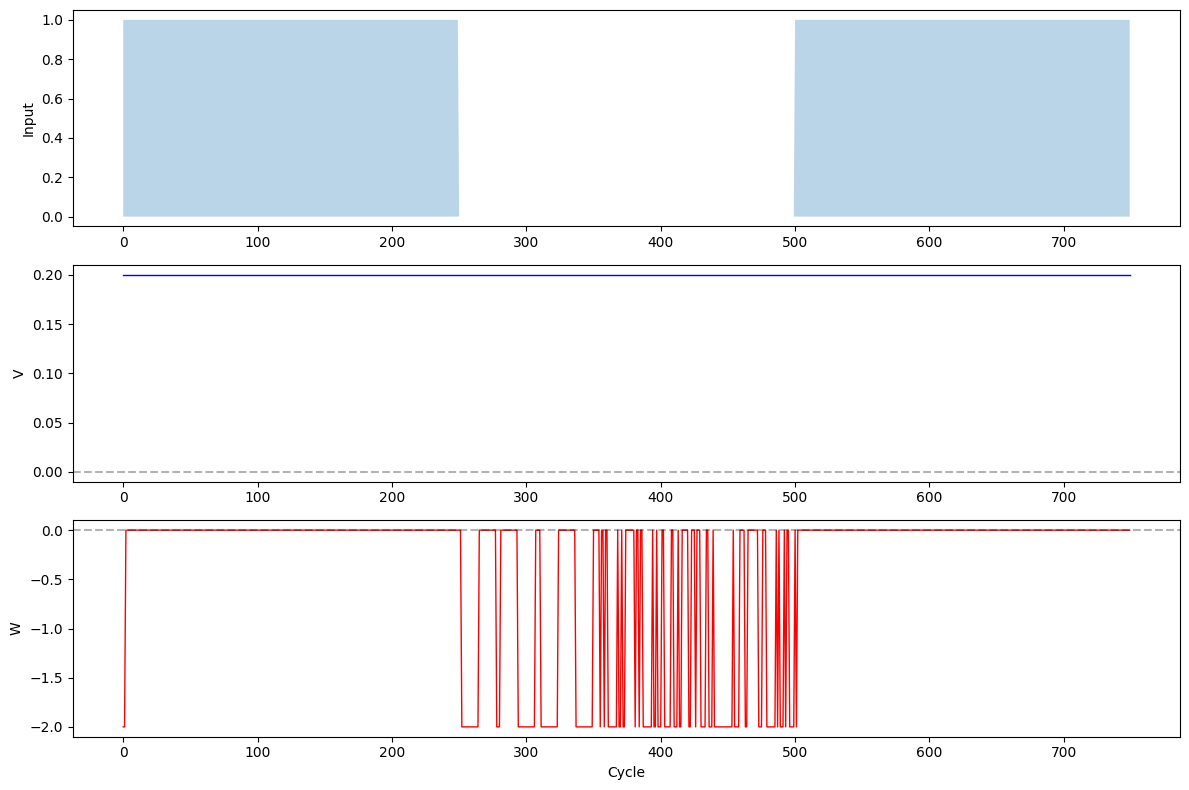

In [135]:
fig, (ax1, ax2, ax3) = plt.subplots(3, 1, figsize=(12, 8))
ax1.fill_between(range(len(df)), df['input'].values, alpha=0.3)
ax1.set_ylabel('Input')

# Plot raw V
ax2.plot(df['v'].values, color='blue', linewidth=1)
ax2.set_ylabel('V')
ax2.axhline(y=0, color='k', linestyle='--', alpha=0.3)

# Plot raw W
ax3.plot(df['w'].values, color='red', linewidth=1)
ax3.set_ylabel('W')
ax3.set_xlabel('Cycle')
ax3.axhline(y=0, color='k', linestyle='--', alpha=0.3)

plt.tight_layout()
plt.show()